In [6]:

import rasterio
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
import openeo

Conectarse al API usando los datos de usuario y contraseña

In [7]:
connection = openeo.connect("https://openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


In [8]:
#Areas de interes
lago_atitlan = {
    "west": -91.326256,
    "east": -91.07151,
    "south": 14.5948,
    "north": 14.750979
}
lago_amatitlan = {
    "west": -90.638065,
    "east": -90.512924, 
    "south": 14.412347,
    "north": 14.493799
}


## Ejercicio 2: Obtención de Datos Raster

Usando `openEO` para descargar B03, B04, B05 y B08 de la colección `SENTINEL2_L2A` para las fechas especificadas.

In [9]:
import os
import datetime
from datetime import date

os.makedirs("data", exist_ok=True)

fechas_atitlan = [
    "2025-01-18", "2025-04-13", "2025-05-13", "2025-07-17",
    "2025-11-21", "2025-12-29", "2026-02-12", "2026-03-24",
    "2026-04-13", "2026-04-28", "2026-07-22"
]

fechas_amatitlan = [
    "2025-01-28", "2025-04-15", "2025-04-28", "2025-11-24",
    "2026-01-08", "2026-02-02", "2026-02-07", "2026-03-29",
    "2026-04-13", "2026-04-28", "2026-06-19"
]

lagos = {
    "atitlan": {"bbox": lago_atitlan, "fechas": fechas_atitlan},
    "amatitlan": {"bbox": lago_amatitlan, "fechas": fechas_amatitlan},
}

def descargar_bandas(lago, bbox, fecha):
    """Descarga B03, B04, B05, B08 para un lago y una fecha, si no existe ya localmente."""
    out_path = f"data/{lago}_{fecha}.tif"
    if os.path.exists(out_path):
        return out_path

    d0 = date.fromisoformat(fecha)
    d1 = d0 + datetime.timedelta(days=1)  # ventana de 1 dia para que openeo encuentre la escena

    cube = connection.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=bbox,
        temporal_extent=[str(d0), str(d1)],
        bands=["B03", "B04", "B05", "B08"],
    )
    cube = cube.reduce_dimension(dimension="t", reducer="mean")
    cube.download(out_path)
    return out_path


In [6]:
# Descarga para ambos lagos (puede tardar varios minutos)
for lago, info in lagos.items():
    for fecha in info["fechas"]:
        try:
            path = descargar_bandas(lago, info["bbox"], fecha)
            print(f"OK: {path}")
        except Exception as e:
            print(f"FALLO {lago} {fecha}: {e}")


OK: data/atitlan_2025-01-18.tif
OK: data/atitlan_2025-04-13.tif
OK: data/atitlan_2025-05-13.tif
OK: data/atitlan_2025-07-17.tif
OK: data/atitlan_2025-11-21.tif
OK: data/atitlan_2025-12-29.tif
OK: data/atitlan_2026-02-12.tif
OK: data/atitlan_2026-03-24.tif
OK: data/atitlan_2026-04-13.tif
OK: data/atitlan_2026-04-28.tif
OK: data/atitlan_2026-07-22.tif
OK: data/amatitlan_2025-01-28.tif
OK: data/amatitlan_2025-04-15.tif
OK: data/amatitlan_2025-04-28.tif
OK: data/amatitlan_2025-11-24.tif
OK: data/amatitlan_2026-01-08.tif
OK: data/amatitlan_2026-02-02.tif
OK: data/amatitlan_2026-02-07.tif
OK: data/amatitlan_2026-03-29.tif
OK: data/amatitlan_2026-04-13.tif
OK: data/amatitlan_2026-04-28.tif
OK: data/amatitlan_2026-06-19.tif


In [10]:
def calcular_indices(tif_path, ndwi_umbral=0.0, offset=1000):
    with rasterio.open(tif_path) as src:
        b03 = src.read(1).astype("float32") + offset
        b04 = src.read(2).astype("float32") + offset
        b05 = src.read(3).astype("float32") + offset
        b08 = src.read(4).astype("float32") + offset

    eps = 1e-6

    def safe_div(num, den):
        out = np.where(den != 0, num / (den + eps), np.nan)
        return out.astype("float32")

    ndvi = safe_div(b08 - b04, b08 + b04)
    ndwi = safe_div(b03 - b08, b03 + b08)
    ndci = safe_div(b05 - b04, b05 + b04)

    ndvi = np.clip(ndvi, -1, 1)
    ndwi = np.clip(ndwi, -1, 1)
    ndci = np.clip(ndci, -1, 1)

    chl = 826.57 * ndci**3 - 176.43 * ndci**2 + 19 * ndci + 4.071
    chl = np.clip(chl, 0, None)

    mascara_agua = ndwi > ndwi_umbral

    return {
        "ndvi": ndvi, "ndwi": ndwi, "ndci": ndci, "chl": chl,
        "mascara_agua": mascara_agua
    }

In [11]:
# OTRA CELDA NUEVA: aplica la función a todas las imágenes descargadas
import pandas as pd

registros = []

for lago, info in lagos.items():
    for fecha in info["fechas"]:
        tif_path = f"data/{lago}_{fecha}.tif"
        if not os.path.exists(tif_path):
            continue
        idx = calcular_indices(tif_path)
        m = idx["mascara_agua"]
        if m.sum() == 0:
            m = np.ones_like(m, dtype=bool)

        registros.append({
            "lago": lago,
            "fecha": pd.to_datetime(fecha),
            "cyano_prom": float(np.nanmean(idx["chl"][m])),
            "ndvi_prom": float(np.nanmean(idx["ndvi"][m])),
            "ndwi_prom": float(np.nanmean(idx["ndwi"][m])),
            "pct_pixeles_agua": float(m.sum() / m.size * 100),
        })

df_indices = pd.DataFrame(registros).sort_values(["lago", "fecha"]).reset_index(drop=True)
df_indices

,lago,fecha,cyano_prom,ndvi_prom,ndwi_prom,pct_pixeles_agua
0,amatitlan,2025-01-28,4.445820,-0.023582,0.061476,12.664860
1,amatitlan,2025-04-15,4.529418,-0.022311,0.085745,12.262653
2,amatitlan,2025-04-28,4.692558,-0.013462,0.090145,11.925797
3,amatitlan,2025-11-24,4.373219,-0.028400,0.055391,12.377157
4,amatitlan,2026-01-08,4.559324,-0.007439,0.051243,11.470749
5,amatitlan,2026-02-02,4.333424,-0.006523,0.025238,11.207582
6,amatitlan,2026-02-07,4.340629,-0.016867,0.043368,12.379803
7,amatitlan,2026-03-29,4.853209,-0.015561,0.090652,12.556210
8,amatitlan,2026-04-13,5.082404,-0.008041,0.102814,12.722112
9,amatitlan,2026-04-28,5.063820,-0.007485,0.120464,10.963179


## Ejercicio #4

In [12]:
# Ejercicio 4.1: índice promedio de cianobacteria por lago y por fecha
tabla_promedios = df_indices[["lago", "fecha", "cyano_prom"]].sort_values(["lago", "fecha"])
tabla_promedios

,lago,fecha,cyano_prom
0,amatitlan,2025-01-28,4.445820
1,amatitlan,2025-04-15,4.529418
2,amatitlan,2025-04-28,4.692558
3,amatitlan,2025-11-24,4.373219
4,amatitlan,2026-01-08,4.559324
5,amatitlan,2026-02-02,4.333424
6,amatitlan,2026-02-07,4.340629
7,amatitlan,2026-03-29,4.853209
8,amatitlan,2026-04-13,5.082404
9,amatitlan,2026-04-28,5.063820


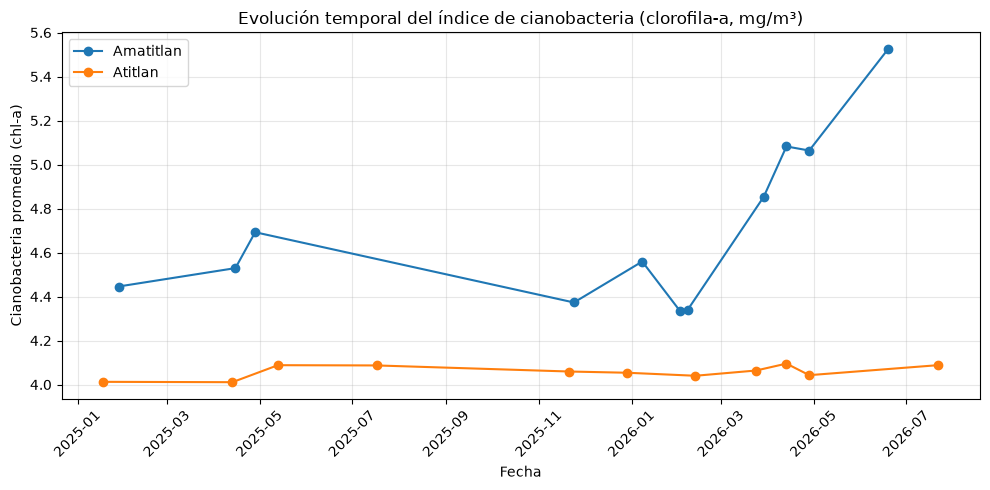

In [13]:
# Ejercicio 4.2: evolución temporal (gráfico de línea por lago)
fig, ax = plt.subplots(figsize=(10, 5))

for lago, grupo in df_indices.groupby("lago"):
    ax.plot(grupo["fecha"], grupo["cyano_prom"], marker="o", label=lago.capitalize())

ax.set_title("Evolución temporal del índice de cianobacteria (clorofila-a, mg/m³)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Cianobacteria promedio (chl-a)")
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("evolucion_temporal_cianobacteria.png", dpi=150)
plt.show()

In [14]:
# Ejercicio 4.3: identificación de picos de floración y fechas críticas
picos = {}
fechas_criticas = {}

for lago, grupo in df_indices.groupby("lago"):
    grupo = grupo.sort_values("fecha")

    idx_max = grupo["cyano_prom"].idxmax()
    picos[lago] = grupo.loc[idx_max]

    umbral = grupo["cyano_prom"].quantile(0.75)
    criticas = grupo[grupo["cyano_prom"] >= umbral]
    fechas_criticas[lago] = criticas[["fecha", "cyano_prom"]]

    print(f"\n{lago.capitalize()}: pico máximo el {picos[lago]['fecha'].date()} con chl-a={picos[lago]['cyano_prom']:.4f}")
    print(f"Fechas críticas (>= percentil 75, umbral={umbral:.4f}):")
    print(criticas[["fecha", "cyano_prom"]].to_string(index=False))

picos_df = pd.DataFrame(picos).T


Amatitlan: pico máximo el 2026-06-19 con chl-a=5.5254
Fechas críticas (>= percentil 75, umbral=4.9585):
     fecha  cyano_prom
2026-04-13    5.082404
2026-04-28    5.063820
2026-06-19    5.525364

Atitlan: pico máximo el 2026-04-13 con chl-a=4.0954
Fechas críticas (>= percentil 75, umbral=4.0876):
     fecha  cyano_prom
2025-05-13    4.088183
2026-04-13    4.095394
2026-07-22    4.088386


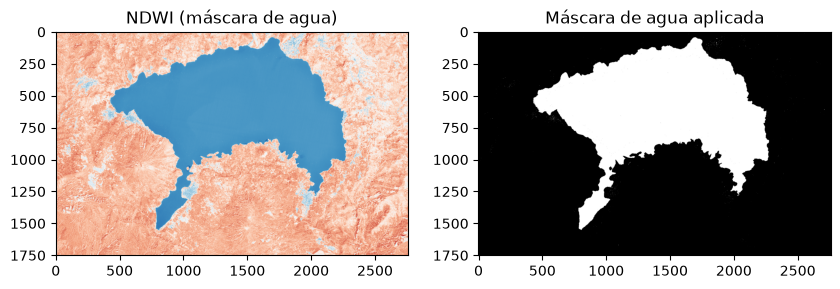

In [15]:
import matplotlib.pyplot as plt

idx = calcular_indices("data/atitlan_2025-01-18.tif")
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(idx["ndwi"], cmap="RdBu")
axs[0].set_title("NDWI (máscara de agua)")
axs[1].imshow(idx["mascara_agua"], cmap="gray")
axs[1].set_title("Máscara de agua aplicada")
plt.show()

NDVI  -> media: 0.0006162936  mediana: 0.0024764736
chl-a -> media: 4.012524  mediana: 4.0214467


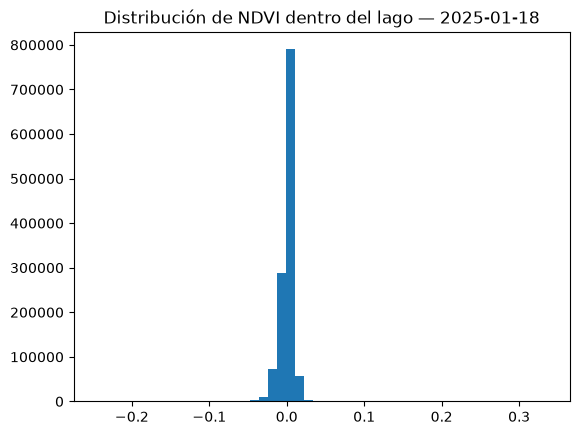

In [16]:
ndvi_agua = idx["ndvi"][idx["mascara_agua"]]
chl_agua = idx["chl"][idx["mascara_agua"]]

print("NDVI  -> media:", np.nanmean(ndvi_agua), " mediana:", np.nanmedian(ndvi_agua))
print("chl-a -> media:", np.nanmean(chl_agua), " mediana:", np.nanmedian(chl_agua))

plt.hist(ndvi_agua, bins=50)
plt.title("Distribución de NDVI dentro del lago — 2025-01-18")
plt.show()

## Ejercicio #5

In [ ]:
import matplotlib
import matplotlib.colors as mcolors

def preparar_overlay(chl, mascara_agua, vmin=None, vmax=None, cmap_name="YlOrRd"):
    valido = mascara_agua & ~np.isnan(chl)

    if vmin is None:
        vmin = np.nanpercentile(chl[valido], 2) if valido.any() else 0
    if vmax is None:
        vmax = np.nanpercentile(chl[valido], 98) if valido.any() else 1

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap = matplotlib.colormaps[cmap_name]
    rgba = cmap(norm(np.nan_to_num(chl)))       # (H, W, 4) floats 0-1
    rgba[..., 3] = np.where(valido, 0.85, 0.0)  # alpha: transparente fuera del agua

    return (rgba * 255).astype(np.uint8), vmin, vmax

### 5.1. Mapea la distribución de cianobacteria dentro de cada lago

In [29]:
import folium
from rasterio.warp import transform_bounds

def mapa_interactivo_cianobacteria(lago, fecha, cmap_name="YlOrRd"):
    tif_path = f"data/{lago}_{fecha}.tif"
    idx = calcular_indices(tif_path)

    with rasterio.open(tif_path) as src:
        # Reproyectar a EPSG:4326 (lat/lon), ya que los .tif vienen en UTM (metros)
        west, south, east, north = transform_bounds(src.crs, "EPSG:4326", *src.bounds)

    rgba, vmin, vmax = preparar_overlay(idx["chl"], idx["mascara_agua"], cmap_name=cmap_name)

    centro = [(south + north) / 2, (west + east) / 2]
    m = folium.Map(location=centro, zoom_start=13, tiles="CartoDB positron")

    folium.raster_layers.ImageOverlay(
        image=rgba,
        bounds=[[south, west], [north, east]],
        opacity=1.0,
        name=f"chl-a {fecha}",
    ).add_to(m)

    folium.map.Marker(
        centro,
        icon=folium.DivIcon(html=f"""<div style="font-size:12px;background:white;
        padding:2px 6px;border-radius:4px;border:1px solid #999;">
        {lago.capitalize()} — {fecha}<br>chl-a: {vmin:.2f} a {vmax:.2f} mg/m³</div>"""),
    ).add_to(m)

    folium.LayerControl().add_to(m)
    return m

In [30]:
def mapa_todas_las_fechas(lago, cmap_name="YlOrRd"):
    fechas = [f for f in lagos[lago]["fechas"] if os.path.exists(f"data/{lago}_{f}.tif")]
    if not fechas:
        print(f"No hay .tif descargados todavía para {lago}")
        return None

    with rasterio.open(f"data/{lago}_{fechas[0]}.tif") as src:
        west0, south0, east0, north0 = transform_bounds(src.crs, "EPSG:4326", *src.bounds)
    centro = [(south0 + north0) / 2, (west0 + east0) / 2]

    m = folium.Map(location=centro, zoom_start=13, tiles="CartoDB positron")

    for i, fecha in enumerate(fechas):
        tif_path = f"data/{lago}_{fecha}.tif"
        idx = calcular_indices(tif_path)
        with rasterio.open(tif_path) as src:
            west, south, east, north = transform_bounds(src.crs, "EPSG:4326", *src.bounds)
        rgba, vmin, vmax = preparar_overlay(idx["chl"], idx["mascara_agua"], cmap_name=cmap_name)

        folium.raster_layers.ImageOverlay(
            image=rgba,
            bounds=[[south, west], [north, east]],
            opacity=1.0,
            name=f"{fecha}  (chl-a {vmin:.1f}-{vmax:.1f})",
            show=(i == 0),  # solo la primera fecha visible al abrir el mapa
        ).add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    return m

mapa_atitlan = mapa_todas_las_fechas("atitlan")
mapa_atitlan
mapa_atitlan.save("mapa_atitlan_todas_fechas.html")  

In [31]:
mapa_amatitlan = mapa_todas_las_fechas("amatitlan")
mapa_amatitlan
mapa_amatitlan.save("mapa_amatitlan_todas_fechas.html")

In [32]:
lago = "amatitlan"
fecha = lagos[lago]["fechas"][0]
tif_path = f"data/{lago}_{fecha}.tif"

idx = calcular_indices(tif_path)
with rasterio.open(tif_path) as src:
    print("CRS:", src.crs)
    print("bounds:", src.bounds)

print("pixeles de agua:", idx["mascara_agua"].sum(), "de", idx["mascara_agua"].size)
print("chl min/max:", np.nanmin(idx["chl"]), np.nanmax(idx["chl"]))

rgba, vmin, vmax = preparar_overlay(idx["chl"], idx["mascara_agua"])
print("alpha max:", rgba[..., 3].max(), "  alpha>0 pixeles:", (rgba[..., 3] > 0).sum())

CRS: EPSG:32615
bounds: BoundingBox(left=754570.0, bottom=1594630.0, right=768170.0, top=1603800.0)
pixeles de agua: 157946 de 1247120
chl min/max: 0.0 178.47289
alpha max: 216   alpha>0 pixeles: 157946


### 5.2. Crea mapas comparativos entre diferentes fechas para cada lago

In [25]:
from scipy import ndimage

def limpiar_mascara(mascara_agua, min_pixeles=30):
    """Quita grupos de pixeles 'agua' aislados (ruido) y deja solo el cuerpo de agua principal."""
    etiquetas, n = ndimage.label(mascara_agua)
    if n == 0:
        return mascara_agua
    tamanos = ndimage.sum(mascara_agua, etiquetas, range(1, n + 1))
    componente_mas_grande = np.argmax(tamanos) + 1
    return etiquetas == componente_mas_grande

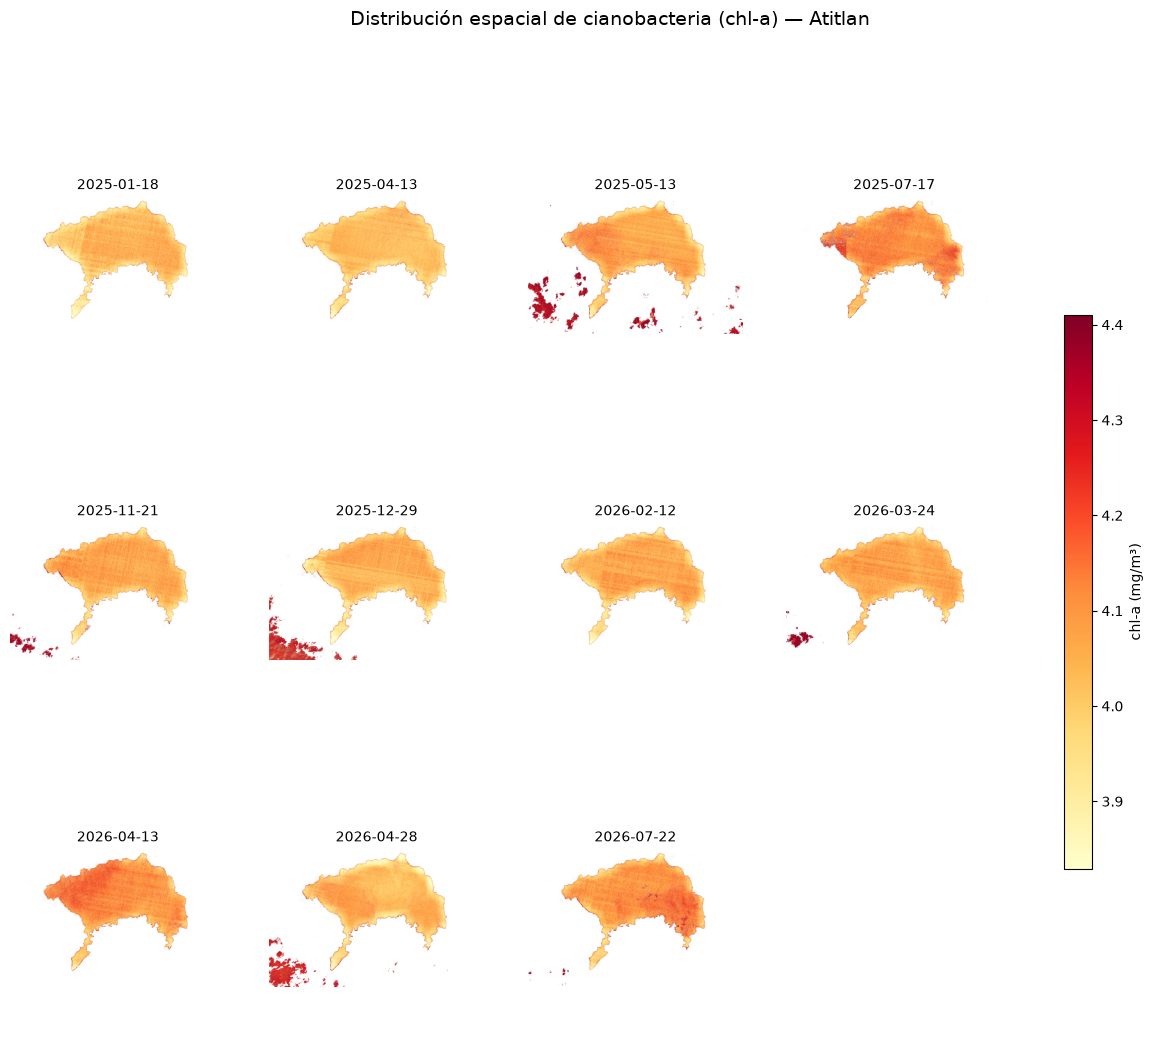

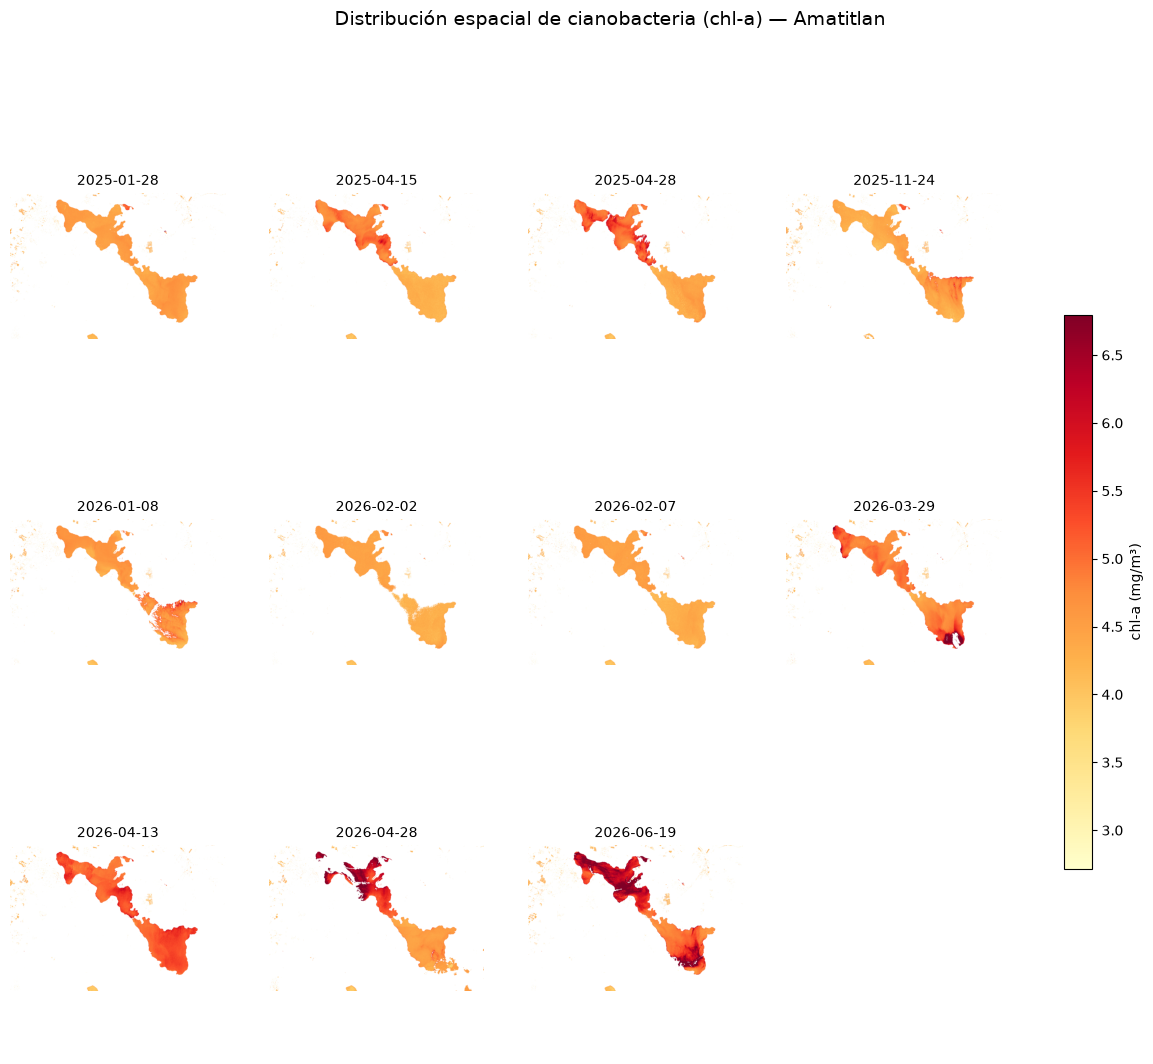

In [26]:
def mapas_comparativos(lago, cmap_name="YlOrRd", cols=4):
    fechas = lagos[lago]["fechas"]
    fechas_validas = [f for f in fechas if os.path.exists(f"data/{lago}_{f}.tif")]

    datos = []
    for f in fechas_validas:
        idx = calcular_indices(f"data/{lago}_{f}.tif")
        chl_agua = np.where(idx["mascara_agua"], idx["chl"], np.nan)
        datos.append((f, chl_agua))

    todos_validos = np.concatenate([d[~np.isnan(d)] for _, d in datos]) if datos else np.array([0, 1])
    vmin, vmax = np.nanpercentile(todos_validos, [2, 98])

    n = len(datos)
    rows = int(np.ceil(n / cols))
    fig, axs = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axs = np.array(axs).reshape(-1)

    im = None
    for ax, (fecha, chl_agua) in zip(axs, datos):
        im = ax.imshow(chl_agua, cmap=cmap_name, vmin=vmin, vmax=vmax)
        ax.set_title(fecha, fontsize=10)
        ax.axis("off")

    for ax in axs[len(datos):]:
        ax.axis("off")

    fig.suptitle(f"Distribución espacial de cianobacteria (chl-a) — {lago.capitalize()}", fontsize=14)
    if im is not None:
        fig.colorbar(im, ax=axs.tolist(), shrink=0.6, label="chl-a (mg/m³)")
    plt.savefig(f"mapas_comparativos_{lago}.png", dpi=150, bbox_inches="tight")
    plt.show()

    return datos

datos_atitlan = mapas_comparativos("atitlan")
datos_amatitlan = mapas_comparativos("amatitlan")

### Patrones espaciales observados: en qué zonas del lago se concentran más los valores altos, si existen áreas persistentes de acumulación y cómo cambia la distribución espacial entre fechas

In [27]:
def mapa_persistencia(lago, datos):
    """datos: lista de (fecha, chl_agua) del mismo shape, viene de mapas_comparativos()."""
    shapes = {a.shape for _, a in datos}
    if len(shapes) > 1:
        print("Aviso: las imágenes no tienen el mismo tamaño de pixel, no se puede apilar:", shapes)
        return None, None

    stack = np.stack([a for _, a in datos])  # (n_fechas, H, W), NaN donde no hay agua/dato
    promedio = np.nanmean(stack, axis=0)
    variabilidad = np.nanstd(stack, axis=0)

    # Escala robusta a outliers (percentiles 2-98), igual que en mapas_comparativos (5.2)
    valido = ~np.isnan(promedio)
    vmin_p, vmax_p = np.nanpercentile(promedio[valido], [2, 98])
    vmin_s, vmax_s = np.nanpercentile(variabilidad[valido], [2, 98])

    fig, axs = plt.subplots(1, 2, figsize=(11, 5))
    im0 = axs[0].imshow(promedio, cmap="YlOrRd", vmin=vmin_p, vmax=vmax_p)
    axs[0].set_title(f"{lago.capitalize()}: chl-a promedio\n(zonas de acumulación persistente)")
    axs[0].axis("off")
    fig.colorbar(im0, ax=axs[0], shrink=0.7, label="chl-a promedio")

    im1 = axs[1].imshow(variabilidad, cmap="viridis", vmin=vmin_s, vmax=vmax_s)
    axs[1].set_title(f"{lago.capitalize()}: variabilidad temporal\n(desviación estándar)")
    axs[1].axis("off")
    fig.colorbar(im1, ax=axs[1], shrink=0.7, label="desviación estándar")

    plt.tight_layout()
    plt.savefig(f"persistencia_{lago}.png", dpi=150)
    plt.show()

    return promedio, variabilidad